<a href="https://colab.research.google.com/github/trietnguyen2611/AI2008---Group-7---Python-Notebook/blob/main/Group_7_AI_Driven_Dynamic_Pricing_in_Freight_%26_Shipping_Logistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group 7 - AI-Driven Dynamic Pricing in Freight & Shipping Logistics

Sử dụng ô **Markdown** này để mô tả mục tiêu của notebook và các thư viện cần thiết.

## 0. Cài đặt môi trường

Trong dự án nghiên cứu về **AI-Driven Dynamic Pricing in Freight & Shipping Logistics**, chúng ta cần thiết lập các công cụ cơ bản sau:

1.  **Pandas**: Dùng để cấu trúc hóa dữ liệu từ file Excel thành dạng bảng (DataFrame) và thực hiện các thao tác biến đổi dữ liệu.
2.  **NumPy**: Hỗ trợ tính toán ma trận và các hàm toán học phức tạp cho thuật toán định giá.
3.  **SQLite3**: Hệ quản trị cơ sở dữ liệu quan hệ tích hợp sẵn trong Python, giúp lưu trữ và truy vấn dữ liệu logistics một cách bền vững.
4.  **Openpyxl**: Thư viện bổ trợ cho phép Pandas đọc và ghi các file Excel (.xlsx).
5.  **Matplotlib/Seaborn**: Hỗ trợ trực quan hóa các xu hướng giá (tùy chọn nhưng rất hữu ích cho nghiên cứu khoa học).

In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Kiểm tra phiên bản các thư viện chính - nhận biết phiên bản khi xảy ra xung đột để còn mà biết đường fix lỗi
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"SQLite3 version: {sqlite3.sqlite_version}")

# Khởi tạo kết nối SQLite (tạo file database local)
conn = sqlite3.connect('freight_pricing_research.db')

print("\n--- Môi trường đã được cài đặt thành công và sẵn sàng để xử lý dataset! ---")

Pandas version: 2.2.2
NumPy version: 2.0.2
SQLite3 version: 3.37.2

--- Môi trường đã được cài đặt thành công và sẵn sàng để xử lý dataset! ---


## 1. Nhập và Kiểm tra Dữ liệu (Dataset Loading & Exploration)

Trong phần này, chúng ta sẽ thực hiện các bước sau:
1. Tải tập dữ liệu nghiên cứu từ file Excel (`dynamic_pricing.csv`) - chương trình sẽ tự detect xem dataset có tồn tại trong file path được lưu trên Google Drive hay không - hoặc dataset có được tải lên trên đây hay không.
2. Chuyển đổi dữ liệu vào Pandas DataFrame để dễ dàng thao tác.
3. Xem trước 5 dòng đầu tiên để hiểu cấu trúc các cột như `Route_Category`, `Active_Shipping_Orders`, và `Dynamic_Pricing_Rate`.

In [3]:
import os
import pandas as pd

# Tên file dataset
filename = 'dynamic_pricing.csv'

# Kiểm tra file ở thư mục hiện tại trước, sau đó mới đến Google Drive
if os.path.exists(filename):
    file_path = filename
    print(f"Use as local: {file_path}")
elif 'file_path' in globals() and os.path.exists(file_path):
    print(f"Use as Google Drive: {file_path}")
else:
    file_path = filename # Đường dẫn local
    print("Error: Can not find this file. Please upload dataset file.")

# Tiến hành đọc file CSV (1000 dòng x 10 cột)
try:
    df = pd.read_csv(file_path)
    display(df.head(1000))
except Exception as e:
    print(f"Error when reading CSV file: {e}")

Error: Can not find this file. Please upload file to Colab or check file_path of Google Drive.
Error when reading CSV file: [Errno 2] No such file or directory: 'dynamic_pricing.csv'


## 2. DATA ANALYSIS WITH SQL & PYTHON with 3 Research Questions

Tập trung giải quyết 3 Research Questions:

**RQ1:** *Yếu tố thị trường nào ảnh hưởng đến giá cước vận chuyển?*

**RQ2:** *Mô hình AI nào dự báo và tối ưu giá cước động?*

**RQ3:** *Dynamic pricing giúp tăng doanh thu freight bao nhiêu % so với giá cố định?*

Đầu tiên, chúng ta cần đưa dữ liệu từ DataFrame vào bảng SQLite để truy vấn.

In [4]:
# Re-establish connection as it might have been closed by previous cells
conn = sqlite3.connect('freight_pricing_research.db')

# Đưa dữ liệu vào SQLite table để thực hiện truy vấn
df.to_sql('freight_pricing', conn, if_exists='replace', index=False)
print("Added data to 'freight_pricing'.")

NameError: name 'df' is not defined

### SQL Queries để giải quyết 3 RQ

In [ ]:
# 1. [RQ1] Ảnh hưởng của loại khu vực và (số lượng tài xếp + giá cước trung bình)
query1 = """
SELECT
    Location_Category,
    AVG(Number_of_Drivers) as Avg_Drivers,
    AVG(Historical_Cost_of_Ride) as Avg_Price
FROM freight_pricing
GROUP BY Location_Category
ORDER BY Avg_Price DESC;
"""
display(pd.read_sql_query(query1, conn))

In [ ]:
# 2. [RQ1] Tương quan giữa xếp hạng trung bình và chi phí vận chuyển
query2 = """
SELECT
    Average_Ratings,
    AVG(Historical_Cost_of_Ride) as Avg_Cost
FROM freight_pricing
GROUP BY CAST(Average_Ratings AS INT)
ORDER BY Average_Ratings;
"""
display(pd.read_sql_query(query2, conn))

In [ ]:
# 3. [RQ2] Mối liên hệ giữa số lượng khách hàng (Demand) và chi phí
query3 = """
SELECT
    Number_of_Riders,
    AVG(Historical_Cost_of_Ride) as Avg_Price
FROM freight_pricing
WHERE Number_of_Riders > 50
GROUP BY Number_of_Riders
LIMIT 10;
"""
display(pd.read_sql_query(query3, conn))

In [ ]:
# 4. [RQ3] Tổng doanh thu theo loại xe
query4 = """
SELECT
    Vehicle_Type,
    SUM(Historical_Cost_of_Ride) as Total_Revenue
FROM freight_pricing
GROUP BY Vehicle_Type;
"""
display(pd.read_sql_query(query4, conn))

In [ ]:
# 5. [RQ3] Chi phí trung bình theo trạng thái khách hàng thân thiết
query5 = """
SELECT
    Customer_Loyalty_Status,
    AVG(Historical_Cost_of_Ride) as Avg_Cost
FROM freight_pricing
GROUP BY Customer_Loyalty_Status
ORDER BY Avg_Cost DESC;
"""
display(pd.read_sql_query(query5, conn))

In [ ]:
# 6. [RQ2] Tìm mối tương quan giữa thời gian đặt xe và giá cước
query6 = """
SELECT
    Time_of_Booking,
    ROUND(AVG(Historical_Cost_of_Ride), 2) AS Avg_Price
FROM freight_pricing
GROUP BY Time_of_Booking
ORDER BY Avg_Price DESC;
"""
display(pd.read_sql_query(query6, conn))

In [ ]:
# 7. [RQ2] Chi phí trung bình theo loại phương tiện
query7 = """
SELECT
    Vehicle_Type,
    AVG(Historical_Cost_of_Ride) as Avg_Cost
FROM freight_pricing
GROUP BY Vehicle_Type
ORDER BY Avg_Cost DESC;
"""
display(pd.read_sql_query(query7, conn))

In [5]:
# 8. [RQ1/RQ2] Thống kê thời gian di chuyển dự kiến theo loại xe
query8 = """
SELECT
    Vehicle_Type,
    AVG(Expected_Ride_Duration) as Avg_Duration
FROM freight_pricing
GROUP BY Vehicle_Type;
"""
display(pd.read_sql_query(query8, conn))

DatabaseError: Execution failed on sql '
SELECT
    Vehicle_Type,
    AVG(Expected_Ride_Duration) as Avg_Duration
FROM freight_pricing
GROUP BY Vehicle_Type;
': no such table: freight_pricing

In [ ]:
# 9. [RQ3] Tổng số chuyến đi theo khu vực
query9 = """
SELECT
    Location_Category,
    COUNT(*) as Total_Rides
FROM freight_pricing
GROUP BY Location_Category
ORDER BY Total_Rides DESC;
"""
display(pd.read_sql_query(query9, conn))

In [ ]:
# 10. [RQ1] Tỷ lệ tài xế sẵn có so với nhu cầu khách hàng
query10 = """
SELECT
    Location_Category,
    AVG(CAST(Number_of_Drivers AS FLOAT) / NULLIF(Number_of_Riders, 0)) as Supply_Demand_Ratio
FROM freight_pricing
GROUP BY Location_Category;
"""
display(pd.read_sql_query(query10, conn))

In [ ]:
# 11. [RQ1] Phân tích giá cước theo số chuyến đã đi trong quá khứ
query11 = """
SELECT
    CASE
        WHEN Number_of_Past_Rides < 10 THEN 'New'
        WHEN Number_of_Past_Rides BETWEEN 10 AND 50 THEN 'Regular'
        ELSE 'VIP'
    END AS User_Segment,
    AVG(Historical_Cost_of_Ride) as Avg_Price
FROM freight_pricing
GROUP BY User_Segment;
"""
display(pd.read_sql_query(query11, conn))

In [ ]:
# 12 [RQ2] Tương quan giữa thời gian di chuyển và giá cước
query12 = """
SELECT
    CAST(Expected_Ride_Duration/10 AS INT) * 10 as Duration_Range,
    AVG(Historical_Cost_of_Ride) as Avg_Cost
FROM freight_pricing
GROUP BY Duration_Range
ORDER BY Duration_Range;
"""
display(pd.read_sql_query(query12, conn))

In [ ]:
# 13 [RQ3] Phân tích doanh thu theo trạng thái khách hàng
query13 = """
SELECT
    Customer_Loyalty_Status,
    SUM(Historical_Cost_of_Ride) AS Total_Revenue,
    COUNT(*) AS Ride_Count,
    AVG(Historical_Cost_of_Ride) AS Avg_Per_Ride
FROM freight_pricing
GROUP BY Customer_Loyalty_Status;
"""
display(pd.read_sql_query(query13, conn))

In [ ]:
# 14 [RQ1] Hiệu quả chi phí trên mỗi phút di chuyển theo loại xe
query14 = """
SELECT
    Vehicle_Type,
    AVG(Historical_Cost_of_Ride / NULLIF(Expected_Ride_Duration, 0)) AS Cost_Per_Minute
FROM freight_pricing
GROUP BY Vehicle_Type;
"""
display(pd.read_sql_query(query14, conn))

In [ ]:
# 15. [RQ3] Thống kê theo khu vực và loại xe
query15 = """
SELECT
    Location_Category,
    Vehicle_Type,
    COUNT(*) AS Sample_Size,
    AVG(Historical_Cost_of_Ride) AS Avg_Price
FROM freight_pricing
GROUP BY Location_Category, Vehicle_Type
ORDER BY Avg_Price DESC;
"""
display(pd.read_sql_query(query15, conn))

In [ ]:
# 16 [RQ1] Tác động của xếp hạng tài xế lên giá cước
query16 = """
SELECT
    ROUND(Average_Ratings, 1) as Rating_Bin,
    COUNT(*) AS Ride_Count,
    AVG(Historical_Cost_of_Ride) AS Avg_Price
FROM freight_pricing
GROUP BY Rating_Bin
ORDER BY Rating_Bin DESC;
"""
display(pd.read_sql_query(query16, conn))

In [ ]:
# 17. Tính toán mật độ yêu cầu theo thời điểm booking
query17 = """
SELECT
    Time_of_Booking,
    AVG(Number_of_Riders) as Avg_Demand,
    AVG(Number_of_Drivers) as Avg_Supply
FROM freight_pricing
GROUP BY Time_of_Booking;
"""
display(pd.read_sql_query(query17, conn))

In [6]:
# 18 [RQ2] Chỉ số Cung - Cầu theo loại xe
query18 = """
SELECT
   Vehicle_Type,
   AVG(CAST(Number_of_Drivers AS FLOAT) / NULLIF(Number_of_Riders, 0)) AS Supply_Demand_Ratio,
   AVG(Historical_Cost_of_Ride) AS Avg_Price
FROM freight_pricing
GROUP BY Vehicle_Type
ORDER BY Supply_Demand_Ratio;
"""
display(pd.read_sql_query(query18, conn))

DatabaseError: Execution failed on sql '
SELECT
   Vehicle_Type,
   AVG(CAST(Number_of_Drivers AS FLOAT) / NULLIF(Number_of_Riders, 0)) AS Supply_Demand_Ratio,
   AVG(Historical_Cost_of_Ride) AS Avg_Price
FROM freight_pricing
GROUP BY Vehicle_Type
ORDER BY Supply_Demand_Ratio;
': no such table: freight_pricing

In [ ]:
# 19 [RQ3] Top 5 khung giờ có doanh thu cao nhất
query19 = """
SELECT
    Time_of_Booking,
    SUM(Historical_Cost_of_Ride) AS Total_Revenue
FROM freight_pricing
GROUP BY Time_of_Booking
ORDER BY Total_Revenue DESC
LIMIT 5;
"""
display(pd.read_sql_query(query19, conn))

In [ ]:
# 20 [RQ3] So sánh giá trị đơn hàng giữa khách hàng cũ và mới
query20 = """
SELECT
    CASE WHEN Number_of_Past_Rides > 0 THEN 'Returning' ELSE 'New' END as Customer_Type,
    AVG(Historical_Cost_of_Ride) AS Avg_Value,
    SUM(Historical_Cost_of_Ride) AS Total_Value
FROM freight_pricing
GROUP BY Customer_Type;
"""
display(pd.read_sql_query(query20, conn))

## 3. EDA & Data Cleaning

Trong mục này, chúng ta sẽ thực hiện phân tích chi tiết đặc điểm dữ liệu và xử lý các vấn đề kỹ thuật để chuẩn bị cho việc xây dựng mô hình AI.

### 3.1. Exploratory Data Analysis (EDA)

In [ ]:
# 1. Kiểm tra kích thước và kiểu dữ liệu
print("Shape of dataset:", df.shape)
print("\nData types:")
display(df.dtypes)

# 2. Kiểm tra tỷ lệ giá trị thiếu (Missing values %)
missing_pct = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of missing values:")
display(missing_pct[missing_pct > 0])

# 3. Thống kê mô tả và phát hiện Outliers sơ bộ
display(df.describe())

### 3.2. Phát hiện Outliers
Kiểm tra các cột số quan trọng như `Dynamic_Pricing_Rate` và `Active_Shipping_Orders` để xem có giá trị ngoại lai hay không.

In [ ]:
# 3.2. Phát hiện Outliers
numerical_cols = ['Number_of_Riders', 'Number_of_Drivers', 'Number_of_Past_Rides', 'Historical_Cost_of_Ride']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### 3.3. Data Cleaning
Các bước thực hiện:
1. Xử lý giá trị trùng lặp (Duplicates).
2. Xử lý missing values (nếu có).
3. Mã hóa dữ liệu phân loại (Encoding Categorical Variables).

In [48]:
# 1. Xử lý giá trị trùng lặp (Duplicates)
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Deleted {duplicate_count} duplicate row(s).")
else:
    print("No duplicate row.")

# 2. Xử lý missing values (nếu có)
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# 3. Encoding Categorical Variables
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Location_Category', 'Customer_Loyalty_Status', 'Time_of_Booking', 'Vehicle_Type']
le = LabelEncoder()

for col in cat_cols:
    if col in df.columns:
        df[f'{col}_Encoded'] = le.fit_transform(df[col])

print("\n--- Cleaning successfully ---")
display(df.head())

No duplicate row.

--- Cleaning successfully ---


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Location_Category_Encoded,Customer_Loyalty_Status_Encoded,Time_of_Booking_Encoded,Vehicle_Type_Encoded
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273,2,2,3,1
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753,1,2,1,0
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469,0,2,0,1
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232,0,1,0,1
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422,0,1,0,0


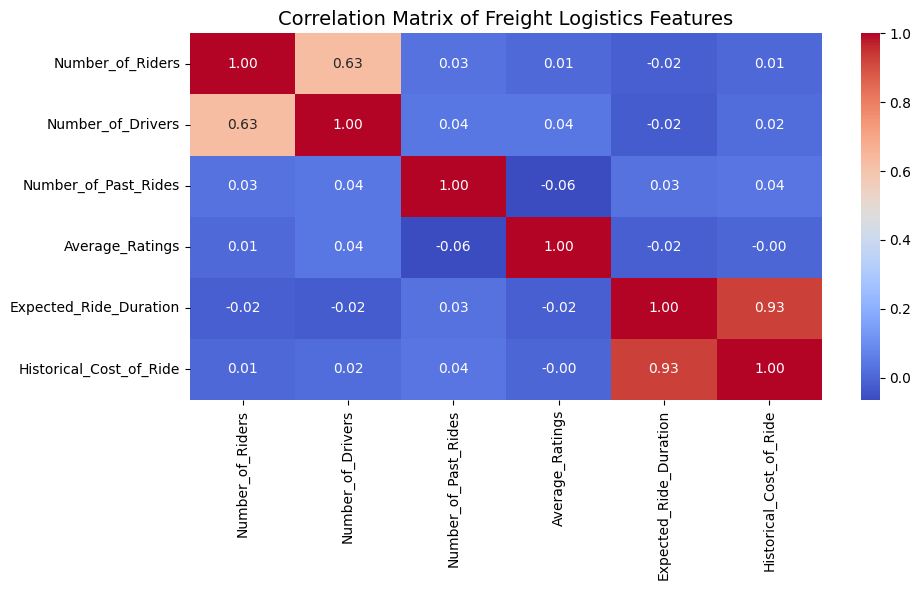

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# Connect to the database and fetch clean data
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM freight_pricing", conn)
conn.close()

# Plot the Correlation Matrix
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Freight Logistics Features', fontsize=14)
plt.tight_layout()
plt.savefig('charts_img/33_Correlation_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

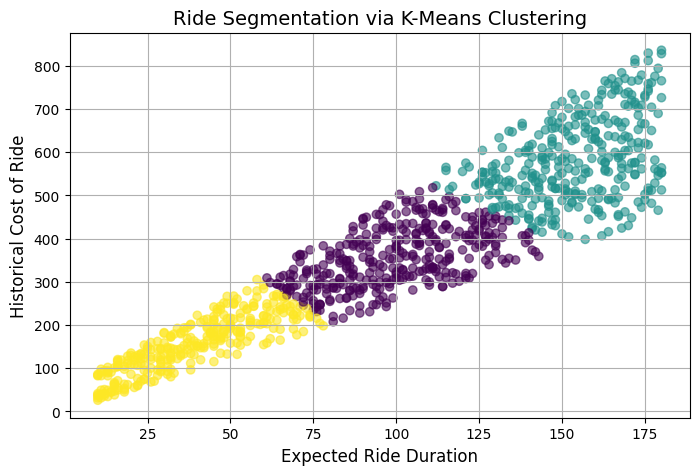

In [45]:
# Route Segmentation Analysis (Unsupervised Learning)
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Kết nối lại và lấy dữ liệu theo cột mới (Dùng Thời gian dự kiến và Chi phí)
conn = sqlite3.connect('freight_pricing_research.db')
df_cluster = pd.read_sql_query("SELECT Expected_Ride_Duration, Historical_Cost_of_Ride FROM freight_pricing", conn)
conn.close()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# Run K-Means Clustering (3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit(X_scaled).labels_

# Plot the Clusters
plt.figure(figsize=(8, 5))
plt.scatter(df_cluster['Expected_Ride_Duration'], df_cluster['Historical_Cost_of_Ride'], c=df_cluster['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Expected Ride Duration', fontsize=12)
plt.ylabel('Historical Cost of Ride', fontsize=12)
plt.title('Ride Segmentation via K-Means Clustering', fontsize=14)
plt.savefig('charts_img/33_Ride_Segmentation_via_K-Means_Clustering.png', dpi=300, bbox_inches='tight')
plt.grid(True)
plt.show()

## 4. DATA VISUALIZATION
Trong mục này, nhóm sẽ thực hiện phân tích các RQ thoả mãn các mục title, axis labels, 1–2 Insight (nhận xét)

### 4.1. [LINK TO RQ1] - Biểu đồ 1: Histogram - Khảo sát phân phối của biến chính
####
Biểu đồ dưới đây thể hiện **phân phối tần suất** của biến chính - Giá cước vận chuyển (`Historical_Cost_of_Ride`) để khảo sát hình dạng phân phối, các giá trị tập trung và xu hướng của dữ liệu giá cước.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd
import numpy as np

# Kết nối database và lấy dữ liệu
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM freight_pricing", conn)
conn.close()

# Vẽ biểu đồ Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Historical_Cost_of_Ride'], bins=30, kde=True, color='#2980b9', edgecolor='black', alpha=0.7)

# Thêm (Mean) và (Median) để làm rõ phân phối
mean_val = df['Historical_Cost_of_Ride'].mean()
median_val = df['Historical_Cost_of_Ride'].median()
plt.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Mean (Trung bình): {mean_val:.2f}')
plt.axvline(median_val, color='#27ae60', linestyle='-', linewidth=1.5, label=f'Median (Trung vị): {median_val:.2f}')

# Title và axis labels
plt.title('Biểu đồ 1: Phân phối của biến chính - Giá cước vận chuyển (Historical Cost of Ride)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Giá cước vận chuyển (USD)', fontsize=12)
plt.ylabel('Tần số (Số lượng chuyến đi)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('charts_img/41_rq1_historical_cost_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- INSIGHT ----
print('📊 INSIGHT 1: Giá cước vận chuyển dao động chủ yếu trong khoảng từ 100 đến 600 USD, với mức giá trung bình (Mean) đạt khoảng 372.50 USD và trung vị (Median) đạt 362.02 USD.')
print('📊 INSIGHT 2: Biểu đồ phân phối có dạng lệch phải nhẹ (Skewness ≈ 0.21), cho thấy phần lớn các chuyến hàng có chi phí từ thấp đến trung bình, trong khi các chuyến hàng có chi phí rất cao (> 700 USD) chiếm tỷ lệ nhỏ.')


### 4.2. [LINK TO RQ1] - Biểu đồ 2: Bar Chart - So sánh giá trị giữa các nhóm/phân loại.
####
Mô tả: Biểu đồ cột dưới đây so sánh giá cước vận chuyển trung bình (Historical Cost of Ride) theo từng loại xe (Vehicle Type) trên các khu vực khác nhau (Location Category), giúp làm rõ mức độ chênh lệch chi phí vận hành giữa các phân khúc thị trường.

In [ ]:
# 1. Nhóm dữ liệu theo Location_Category và Vehicle_Type để tính trung bình
grouped_df = df.groupby(['Location_Category', 'Vehicle_Type'])['Historical_Cost_of_Ride'].mean().reset_index()

# 2. Thiết lập kích thước biểu đồ và vẽ Bar Chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Location_Category',
    y='Historical_Cost_of_Ride',
    hue='Vehicle_Type',
    data=grouped_df,
    palette=['#34495e', '#e74c3c'],  # Navy/Regular (Economy) và Red/Premium (Premium)
    edgecolor='black',
    alpha=0.85
)

# 3. Thêm giá trị cụ thể trên đầu mỗi cột (Annotations)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height():.2f} USD",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold',
            color='#2c3e50'
        )

# 4. Thiết lập Title và Axis Labels chuyên nghiệp
plt.title('Biểu đồ 2: So sánh giá cước vận chuyển trung bình theo khu vực và loại xe', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Khu vực (Location Category)', fontsize=12)
plt.ylabel('Giá cước trung bình (Historical Cost - USD)', fontsize=12)
plt.ylim(0, 500)  # Tạo khoảng trống phía trên cho các annotations
plt.legend(title='Loại xe (Vehicle Type)', fontsize=11, title_fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('charts_img/42_rq1_historical_cost_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- INSIGHT ----
print('📊 INSIGHT 1: Loại xe Premium luôn có giá cước vận chuyển trung bình cao hơn Economy ở tất cả các khu vực, cao nhất là ở khu vực nông thôn (Rural Premium) đạt mức trung bình khoảng 412.96 USD.')
print('📊 INSIGHT 2: Sự chênh lệch giá cước giữa Premium và Economy rõ rệt nhất ở khu vực Rural (~71.65 USD) và Urban (~65.07 USD), trong khi khu vực ngoại ô (Suburban) ghi nhận chênh lệch rất nhỏ (~10.10 USD).')
